# 03 - CNN Classifier (supervisionado) — metodologia corrigida

Modelo 2. CNN supervisionada (normal vs defeito).

> **Correção vs versão antiga:** antes juntava-se tudo e fazia-se um
> `train_test_split` aleatório que **misturava `test/good` no treino** (accuracy
> inflada ~0.95). Agora seguimos `scripts/train_eval_cnn_bottle.py`: as normais
> de treino são as oficiais (`train/good`), e **só os defeitos do `test/`** são
> divididos em treino/avaliação (estratificado). Saída sigmoid + `class_weight`.
>
> ⚠️ Continua a ser um **baseline ilustrativo não comparável** ao protocolo de
> anomalia (o MVTec não tem defeitos no treino).

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import torch
from utils import set_seed, get_device

set_seed(42)
device = get_device()
print("device:", device)

import tensorflow as tf
tf.keras.utils.set_random_seed(42)

device: cuda


## 1. Dados — normais oficiais + defeitos do teste divididos (sem misturar)

In [2]:
from bottle_protocol import bottle_test_records, bottle_train_good_paths
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

IMG = 128
def load_image(path):
    img = Image.open(path).convert("RGB").resize((IMG, IMG))
    return np.asarray(img, dtype=np.float32) / 255.0

# Só os defeitos do test/ entram no split treino/avaliação (estratificado).
official_test = bottle_test_records()
test_paths = np.asarray([r.path for r in official_test], dtype=object)
test_labels = np.asarray([r.label for r in official_test], dtype=int)
sup_train_paths, eval_paths, sup_train_labels, eval_labels = train_test_split(
    test_paths, test_labels, test_size=0.4, random_state=42, stratify=test_labels
)

# Normais de treino = train/good oficial (nunca vêm do teste).
normal_paths = np.asarray(bottle_train_good_paths(), dtype=object)
normal_labels = np.zeros(len(normal_paths), dtype=int)

train_paths = np.concatenate([normal_paths, sup_train_paths])
train_labels = np.concatenate([normal_labels, sup_train_labels])

x_train = np.stack([load_image(p) for p in train_paths]); y_train = train_labels.astype(np.float32)
x_eval = np.stack([load_image(p) for p in eval_paths]); y_eval = eval_labels.astype(np.float32)

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_labels)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print("Treino:", x_train.shape, "| Avaliação:", x_eval.shape, "| class_weight:", class_weight)

Treino: (258, 128, 128, 3) | Avaliação: (34, 128, 128, 3) | class_weight: {0: 0.583710407239819, 1: 3.4864864864864864}


## 2. Modelo CNN (Sequential, saída sigmoid)

In [3]:
from keras.layers import Conv2D, Dense, Flatten, Input, MaxPool2D
from keras.models import Sequential

model = Sequential([
    Input(shape=(IMG, IMG, 3)),
    Conv2D(32, (3, 3), activation="relu"), MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"), MaxPool2D((2, 2)),
    Flatten(), Dense(128, activation="relu"),
    Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Treino

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.5991 - loss: 0.7058 - val_accuracy: 0.2308 - val_loss: 1.2756
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.9267 - loss: 0.5338 - val_accuracy: 0.2308 - val_loss: 1.0613
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.9267 - loss: 0.4824 - val_accuracy: 0.2308 - val_loss: 1.1547
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9267 - loss: 0.4561 - val_accuracy: 0.2308 - val_loss: 1.1000
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9095 - loss: 0.3980 - val_accuracy: 0.2308 - val_loss: 1.4993
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9440 - loss: 0.3101 - val_accuracy: 0.2308 - val_loss: 2.1394
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9052 - loss: 0.3373 - val_accuracy: 0.2308 - val_loss: 1.1445
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.8707 - loss: 0.3069 - val_accuracy: 0.

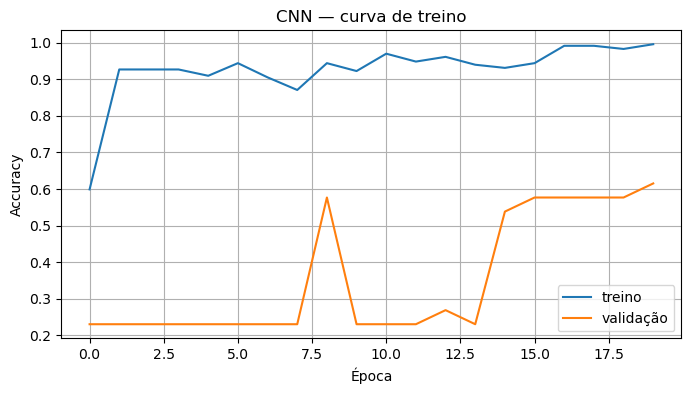

In [4]:
historico = model.fit(
    x_train, y_train, epochs=20, batch_size=16,
    validation_split=0.1, class_weight=class_weight, verbose=1,
)
plt.figure(figsize=(8, 4))
plt.plot(historico.history["accuracy"], label="treino")
plt.plot(historico.history["val_accuracy"], label="validação")
plt.xlabel("Época"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.title("CNN — curva de treino"); plt.show()

## 4. Avaliação (matriz de confusão + relatório)

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

probs = model.predict(x_eval, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)

print("Matriz de Confusão:")
print(confusion_matrix(y_eval, preds))
print("\nRelatório de Classificação:")
print(classification_report(y_eval.astype(int), preds, target_names=["normal", "defeito"], zero_division=0))

Matriz de Confusão:
[[ 8  0]
 [15 11]]

Relatório de Classificação:
              precision    recall  f1-score   support

      normal       0.35      1.00      0.52         8
     defeito       1.00      0.42      0.59        26

    accuracy                           0.56        34
   macro avg       0.67      0.71      0.56        34
weighted avg       0.85      0.56      0.58        34



## 5. Exemplos classificados (verde = acertou, vermelho = errou)

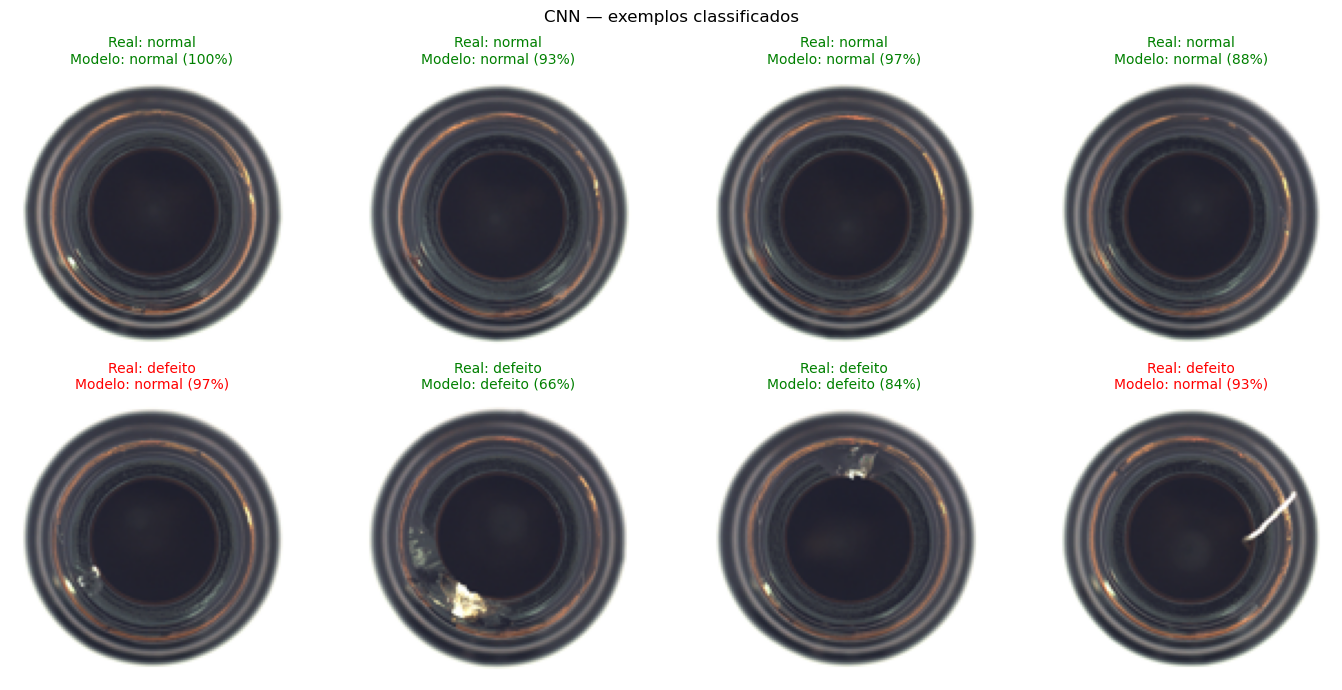

In [6]:
nomes = ["normal", "defeito"]
rng = np.random.default_rng(7)
nm = np.where(eval_labels == 0)[0]; df = np.where(eval_labels == 1)[0]
idx = np.concatenate([rng.choice(nm, min(4, len(nm)), replace=False),
                      rng.choice(df, min(4, len(df)), replace=False)])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), idx):
    x = load_image(eval_paths[i])
    prob = float(model.predict(x[None, ...], verbose=0).ravel()[0])
    pred = int(prob >= 0.5); conf = prob if pred == 1 else 1 - prob
    ax.imshow(x); ax.axis("off")
    cor = "green" if pred == eval_labels[i] else "red"
    ax.set_title(f"Real: {nomes[eval_labels[i]]}\nModelo: {nomes[pred]} ({conf*100:.0f}%)", color=cor, fontsize=10)
plt.suptitle("CNN — exemplos classificados"); plt.tight_layout(); plt.show()